![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# **SESSION 6. FINAL PROJECT**
##### **(De)multiplexer based on cascaded Mach-Zehnder Interferometers (MZIs)**

Nadia Martí García

## **Part 1: Design and simulation of individual components**
---


In [96]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import pandas as pd

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

import gdsfactory as gf
#import jax
#import jax.example_libraries.optimizers as opt
#import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs

from upvfab_design_tools import MMI_EME, DC_EME


In [97]:
nm = 1e-3
wvl = np.linspace(1500, 1600, 200) * nm
f = td.C_0 / wvl
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

##### **1. Simulating Propagation Modes in SOI Waveguides** 
### 1.1 Define the SOI waveguide structure (450 nm width, 220 nm thickness).

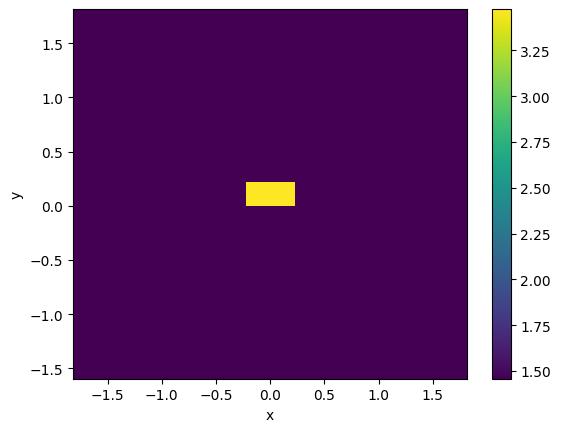

In [98]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=0.45, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    group_index_step= 10 * nm
)

deep_waveguide.plot_index()

### 1.2 Simulate fundamental TE and TM modes. 

In [99]:
te= deep_waveguide.fraction_te
tm= deep_waveguide.fraction_tm

print( "fraction_te=", te)
print( "fraction_tm=", tm)

2026-05-22 14:10:02.367 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_dfb3dde41810a0ba.npz.
fraction_te= [0.960726   0.06940437 0.64309704 0.99810644]
fraction_tm= [0.039274   0.93059563 0.35690296 0.00189356]


Modos TE: 0,2,3\
Modos TM: 1,2

Text(0.5, 1.0, 'Modo 0 TE')

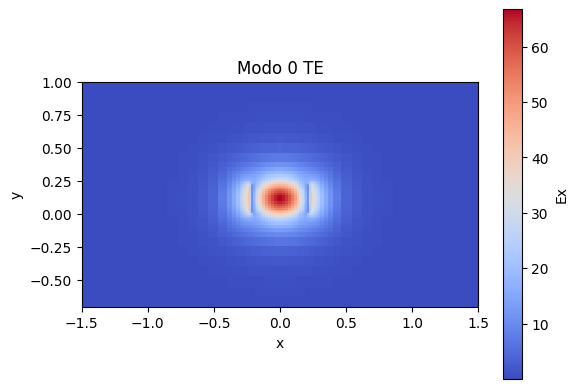

In [100]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('Modo 0 TE') # You might need this later :) 

Text(0.5, 1.0, 'Modo 1 TM')

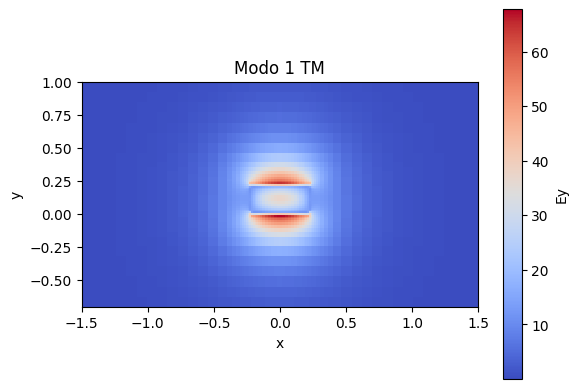

In [101]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('Modo 1 TM') # You might need this later :) 

### 1.3 Extract effective index (n_eff) and group index (n_g) values. 

In [ ]:
lambdas_ref = SOI[:, 0]
indice_te = SOI[:, 3] 
indice_tm = SOI[:, 5] 

# Redefinimos el rango de longitudes de onda con 1000 puntos
wvl_1000= np.linspace(1.48, 1.60, 1000) 

# Creamos los modelos de interpolación
modelo_interp_te = interp1d(lambdas_ref, indice_te, fill_value="extrapolate", bounds_error=False)
modelo_interp_tm = interp1d(lambdas_ref, indice_tm, fill_value="extrapolate", bounds_error=False)

# Evaluación de los índices efectivos
n_eff_te_sim = modelo_interp_te(wvl_1000)
n_eff_tm_sim = modelo_interp_tm(wvl_1000)


derivada_te = np.gradient(n_eff_te_sim, wvl_1000)
n_g_te_sim = n_eff_te_sim - (wvl_1000 * derivada_te)

derivada_tm = np.gradient(n_eff_tm_sim, wvl_1000)
n_g_tm_sim = n_eff_tm_sim - (wvl_1000 * derivada_tm)


# Devolvemos solo las longitudes de onda requeridas
target_wls_nm = [1510, 1530, 1550, 1570]

print("--- Parámetros Ópticos SOI (Modo TE) ---")
for wl_nm in target_wls_nm:
    wl_um = wl_nm / 1000.0
    
    # Buscamos la posición exacta en el array de simulación minimizando la diferencia
    idx = np.argmin(np.abs(wvl_1000 - wl_um))
    
    # Extraemos los valores
    neff_val = n_eff_te_sim[idx]
    ng_val = n_g_te_sim[idx]
    
    print(f"λ = {wl_nm} nm  -->  n_eff = {neff_val:.5f}  |  n_g = {ng_val:.5f}")

--- Parámetros Ópticos SOI (Modo TE) ---
λ = 1510 nm  -->  n_eff = 2.40550  |  n_g = 4.27794
λ = 1530 nm  -->  n_eff = 2.38078  |  n_g = 4.27794
λ = 1550 nm  -->  n_eff = 2.35573  |  n_g = 4.29327
λ = 1570 nm  -->  n_eff = 2.33080  |  n_g = 4.29326


#### **2. Designing Directional Couplers** 
Objective: Achieve coupling constants as shown in Figure 5(b). 
### 2.1. Simulate directional couplers in GDSFactory.

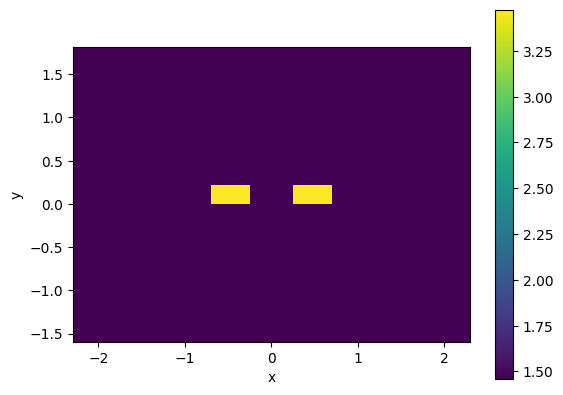

In [103]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(0.45, 0.45), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=220 * nm, # Waveguide height 
    gap=500 * nm,
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

In [104]:
dcoupler_neff = dcoupler_cs.n_eff
dcoupler_cs.fraction_tm
dcoupler_cs.fraction_te

print( f"Effective index: {dcoupler_neff}")
print( f"Fraction TE: {dcoupler_cs.fraction_te}")
print( f"Fraction TM: {dcoupler_cs.fraction_tm}")

2026-05-22 14:10:03.569 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_2aeba57398dab395.npz.
Effective index: [2.35906687+6.54119878e-05j 2.35622601+6.44152336e-05j
 1.76958963+2.33312765e-04j 1.73585575+2.44855661e-04j]
Fraction TE: [0.96701886 0.96704485 0.06437904 0.07364214]
Fraction TM: [0.03298114 0.03295515 0.93562096 0.92635786]


### 2.2. and 2.3. Sweep different gap values and coupling lengths. Extract coupling coefficients (e.g., 0.5, 0.3, 0.23, etc.). 

In [105]:
nm = 1e-3
lambda_0 = 1.55 
target_kappas = [0.5, 0.3, 0.23, 0.17, 0.05]  

# Definimos el rango de Gaps para el barrido (um)
gaps = np.array([0.1, 0.2, 0.3, 0.4, 0.5]) 

results = []


for g in gaps:
    dcoupler = gt.modes.WaveguideCoupler(
        core_width=(0.45, 0.45),  # 450nm 
        core_thickness=0.22,      # 220nm 
        slab_thickness=0,
        gap=g,
        core_material='si',      
        clad_material='sio2',    
        wavelength=lambda_0,
        num_modes=2,              
        precision='double',
        grid_resolution=30        
    )

    # Extraer índices efectivos de los modos par (index 0) e impar (index 1) modo TE
    
    neff_even = dcoupler.n_eff[0].real
    neff_odd = dcoupler.n_eff[1].real
    
    # Calcular la longitud de acoplamiento (Lc)
    Lc = lambda_0 / (2 * (neff_even - neff_odd))
    
    # Para cada kappa objetivo, calcular la longitud L necesaria
    for kappa_sq in target_kappas:
        L_needed = (2 * Lc / np.pi) * np.arcsin(np.sqrt(kappa_sq))
        results.append({
            "Gap (um)": g,
            "Target Kappa^2": kappa_sq,
            "Lc (um)": round(Lc, 2),
            "Length L (um)": round(L_needed, 2)
        })

# RESULTADOS 
df_results = pd.DataFrame(results)
print("\n--- Tabla de Diseño para Acopladores Direccionales ---")
print(df_results)


2026-05-22 14:10:03.611 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from C:\Users\cfp\.gdsfactory\modes\WaveguideCoupler_dbb7d8ddc6e74798.npz.
2026-05-22 14:10:03.620 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from C:\Users\cfp\.gdsfactory\modes\WaveguideCoupler_0ca60a08e75b8e87.npz.
2026-05-22 14:10:03.633 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from C:\Users\cfp\.gdsfactory\modes\WaveguideCoupler_c1984585980421f0.npz.
2026-05-22 14:10:03.641 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from C:\Users\cfp\.gdsfactory\modes\WaveguideCoupler_4870a47a60d3d724.npz.
2026-05-22 14:10:03.646 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from C:\Users\cfp\.gdsfactory\modes\WaveguideCoupler_3338efd24f964229.npz.

--- Tabla de Diseño para Acopladores Direccionales ---
    Gap (um)  Target Kappa^2  Lc (um)  Length L (um)
0        0.1            0.50    10.21           5.11
1        0.1            0.30    10.21           3.77
2    

#### **3. Cascaded MZI Filter and SAX Model**

### 3.1. Definición en SAX de las guías de onda y los couplers

In [106]:
import sax
import numpy as np

# --- 1. Waveguide Model (SOI 450nm x 220nm) ---
def waveguide(wl=1.55, neff= 1.6072, length=23.25, loss=0.0) -> sax.SDict:
    """"
    neff, ng = 2.35636369, 4.26896862 #Los datos obtenidos en 1 c) para 1.55um
    dwl= wl -wl0
    dneff_dwl = (ng - neff) / wl0
    neff = neff - dneff_dwl * dwl
    """
    phase = 2 * np.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * np.exp(1j * phase)
    
    wg_dict = sax.reciprocal({
        ("in0", "out0"): transmission,
    })
    return wg_dict

# --- 2. Coupler Model ---
def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal({
        ("in0", "out0"): tau,
        ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
        ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
        ("in1", "out1"): tau,
    })
    return coupler_dict


### 3.2. Cálculo de las longitudes L1 y L2 de S1 y S2


##### 3.2.1. Etapa S1

Los canales que queremos demultiplexar están en 1.51, 1.53, 1.55 y 1.57 µm, así que la longitud de onda central es $\lambda_0 = 1.54\,\mu\text{m}$.

A partir de la función de transferencia del MZI, $$I_0 = \frac{I_i}{2}\left(1 + \cos(\Delta\phi)\right)$$ imponemos que la potencia de salida sea la mitad de la de entrada en $\lambda_0$, lo que nos da la condición sobre la diferencia de fase:

$$
\Delta\phi = \frac{\pi}{2} + 2\pi m
$$

Relacionando la fase con la diferencia de longitud entre brazos mediante $\Delta\phi = \frac{2\pi n_{\text{eff}}}{\lambda}\Delta L$, y teniendo en cuenta que S1 tiene tres bloques MZI en cascada, llegamos a:

$$
L_1 - L_2 = \frac{\lambda_0}{3\,n_{\text{eff}}}\left(m + \frac{1}{4}\right)
$$

Además, para que cada longitud de onda salga por el puerto correcto se añade una longitud extra equivalente a un desfase de $\pi$:

$$
\Delta L_{\pi} = \frac{\lambda_0}{2\,n_{\text{eff}}}
$$

Una vez calculadas las longitudes, hay que determinar el valor de $m$ que nos da un FSR de 40 nm. Para ello igualamos la expresión general del FSR con la de $\Delta L$:

$$
\frac{\lambda_0^2}{n_g \cdot \text{FSR}} = \left(m + \frac{1}{4}\right)\frac{\lambda_0}{3\,n_{\text{eff}}} + \frac{\lambda_0}{2\,n_{\text{eff}}}
$$

y despejamos $m$.



#### 3.2.2. Etapa S2

Igual que en S1 con dos cambios:

- Longitud de onda central: $\lambda_0 = 1.53\,\mu\text{m}$
- Desfase adicional de $\pi/2$ en el bloque inferior del circuito:

$$
\Delta L_{\pi/2} = \frac{\lambda_0}{4\,n_{\text{eff}}}


In [138]:
# Asignamos el índice efectivo y de grupo de la guía base (450 nm, modo TE)
n_eff_base = n_eff_te_sim 
n_g_base = n_g_te_sim 

# Encontramos los índices en el vector de longitudes de onda 
idx_1530_nm = np.argmin(np.abs(wvl_1000 - 1.530))
idx_1540_nm = np.argmin(np.abs(wvl_1000 - 1.540))
idx_1550_nm = np.argmin(np.abs(wvl_1000 - 1.550))

# Etapa S1 (FSR = 40 nm) 
fsr_s1_um = 40e-3  # 40 nm pasados a μm

# Extracción de parámetros evaluados a 1540 nm
wvl_s1 = wvl_1000  [idx_1540_nm]
n_eff_s1 = n_eff_base[idx_1540_nm]
n_g_s1 = n_g_base[idx_1540_nm]

# Fórmula matemática para S1
m_fsr_40 = (3 * wvl_s1 * n_eff_s1) / (n_g_s1 * fsr_s1_um) - 1/4 + 3/2

print(f"Orden 'm' para la etapa S1 (FSR = 40 nm): {m_fsr_40:.4f}")

# Etapa S2 (FSR = 80 nm) 
fsr_s2_um = 80e-3  # 80 nm pasados a μm

# Extracción de parámetros evaluados a 1530 nm
wvl_s2 = wvl_1000[idx_1530_nm]
n_eff_s2 = n_eff_base[idx_1530_nm]
n_g_s2 = n_g_base[idx_1530_nm]

# Fórmula matemática para S2
m_fsr_80 = (wvl_s2 * n_eff_s2) / (n_g_s2 * fsr_s2_um) - 1/4

print(f"Orden 'm' para la etapa S2 (FSR = 80 nm): {m_fsr_80:.4f}")

Orden 'm' para la etapa S1 (FSR = 40 nm): 64.9620
Orden 'm' para la etapa S2 (FSR = 80 nm): 10.3933


In [152]:
# -----------Longitudes etapa S1 
m_s1 = 65
l2_s1 = 10.0

# Desfase de pi
L_pi_s1 = wvl_s1 / (2 * n_eff_s1)

# Longitud del brazo 1 (l1_s1) despejada de la condición de fase
l1_s1 = (
    (wvl_s1 / (3 * n_eff_s1)) * m_s1
    + (wvl_s1 / (12 * n_eff_s1))
    + l2_s1
    + L_pi_s1
)

# Coeficientes de acoplo para S1
k_s1 = [0.5, 0.17, 0.23, 0.05]


print("--- Etapa S1 ---")
print(f"L1: {l1_s1:.4f} μm")
print(f"L2: {l2_s1:.4f} μm")

--- Etapa S1 ---
L1: 24.4674 μm
L2: 10.0000 μm


In [ ]:
# -----------Longitudes etapa S2 
m_s2 = 10
l1_s2 = 5.0  # En S2 partimos fijando la longitud del brazo l1

# Extraemos los valores a 1530 nm y 1550 nm
wvl_1530 = wvl_1000[idx_1530_nm]
neff_1530 = n_eff_base[idx_1530_nm]
wvl_1550 = wvl_1000[idx_1550_nm]
neff_1550 = n_eff_base[idx_1550_nm]

# Desfases adicionales para alinear los canales
despl_s2_up = wvl_1550 / (2 * neff_1550)
despl_s2_b = wvl_1530 / (4 * neff_1530) 

# Longitud del brazo 2 (l2_s2) 
l2_s2 = (
    (m_s2 * wvl_1530) / neff_1530
    + wvl_1530 / (4 * neff_1530)
    + l1_s2
    + despl_s2_up
)

# Coeficientes de acoplo para S2
k_s2 = [0.5, 0.3, 0.05]


print("\n--- Etapa S2 ---")
print(f"L1: {l1_s2:.4f} μm")
print(f"L2 (superior): {l2_s2:.4f} μm")
print(f"L2 (inferior): {l2_s2 + despl_s2_b:.4f} μm")


--- Etapa S2 ---
L1: 5.0000 μm
L2 (superior): 11.9160 μm
L2 (inferior): 12.0767 μm


In [154]:
# Interpolación del índice efectivo a la longitud de onda central (1.55 μm)
lambda_0 = 1.55
n1_1550 = np.interp(lambda_0, wvl_1000, n_eff_base)

# Cálculo de la longitud extra para el desfase de pi (evaluado a 1540 nm)
L_pi_s1 = float(wvl_1000[idx_1540_nm] / (2 * n_eff_base[idx_1540_nm]))

print(f"L_pi_s1: {L_pi_s1:.4f} μm")

L_pi_s1: 0.3251 μm


### 3.3. Diseño de S1

A continuación vamos a definir la etapa S1, estamos construyendo una estructura de **Interferómetros Mach-Zehnder (MZI) en cascada** de 3 etapas.

* **`instances`**: Declaramos los bloques fundamentales del circuito. En este caso, los 4 acopladores direccionales (`coup_a`, `coup_b`, `coup_c`, `coup_d`) y 3 pares de guías de onda que actúan como los brazos desfasadores del MZI (brazos superiores `wvg_u` y brazos inferiores `wvg_d`).
* **`connections`**: Definimos la topología del diseño enrutando las conexiones ópticas. Conectamos secuencialmente las salidas de cada acoplador direccional a las entradas de los brazos del MZI, y las salidas de estos brazos a las entradas del siguiente acoplador. 
* **`ports`**: Establecemos cuáles serán los puertos de entrada y salida globales (las entradas del primer acoplador `coup_a` y las salidas del último acoplador `coup_d`).
* **`models`**: Mapeamos los nombres lógicos que hemos usado en las `instances` con los modelos de la matriz de dispersión (S-matrix) correspondientes (`coupler` y `waveguide`) para que SAX pueda realizar la simulación espectral.

In [155]:
#Definición del circuito S1

s1_def, info = sax.circuit(
    netlist={
        "instances": {
            "coup_a": "coupler",
            "wvg_u1": "waveguide",
            "wvg_d1": "waveguide",
            "coup_b": "coupler",

            "wvg_u2": "waveguide",
            "wvg_d2": "waveguide",

            "coup_c": "coupler",
            "wvg_u3": "waveguide",
            "wvg_d3": "waveguide",
            "coup_d": "coupler",
        },
        "connections": {
            # Acoplador A -> Guías 1
            "coup_a,out0": "wvg_u1,in0",
            "wvg_u1,out0": "coup_b,in0",
            "coup_a,out1": "wvg_d1,in0",
            "wvg_d1,out0": "coup_b,in1",

            # Acoplador B -> Guías 2
            "coup_b,out0": "wvg_u2,in0",
            "wvg_u2,out0": "coup_c,in0",
            "coup_b,out1": "wvg_d2,in0",
            "wvg_d2,out0": "coup_c,in1",

            # Acoplador C -> Guías 3
            "coup_c,out0": "wvg_u3,in0",
            "wvg_u3,out0": "coup_d,in0",
            "coup_c,out1": "wvg_d3,in0",
            "wvg_d3,out0": "coup_d,in1",
        },
        "ports": {
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_d,out0",
            "out1": "coup_d,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

**Asignación de Parámetros:**
* **Longitudes de los brazos:** Se definen las longitudes base $L_1$ y $L_2$, así como un pequeño incremento $L_\pi$ que introduce un desfase de $\pi$.
* **Coeficientes de acoplo ($k$):** Se establecen valores constantes para los cuatro acopladores direccionales ($k_a = 0.5$, $k_b = 0.17$, $k_c = 0.23$, $k_d = 0.05$). 
* **Pérdidas:** Se configuran las pérdidas a cero ($\alpha = 0$) para observar el comportamiento ideal del multiplexor sin atenuación en las guías.

**Evaluación del modelo S1:**
Introducimos estos parámetros en `s1_def`. Las longitudes de los brazos de las etapas siguen el siguiente modelo:

![My Image](Etapa_s1.PNG)

**Análisis de la Gráfica (Transmisión vs. Longitud de Onda):**
* **FSR:** Observamos una periodicidad clara de **40 nm** entre los picos de máxima transmisión. 
* **Respuesta del Filtro:** A diferencia de la forma sinusoidal de un único MZI, la gráfica nos muestra picos ligeramente más aplanados y valles más anchos y profundos. Esto nos indica que el efecto de la cascada: mejora el *roll-off* (la caída de la señal) por lo que aumenta la tolerancia a variaciones de fabricación.

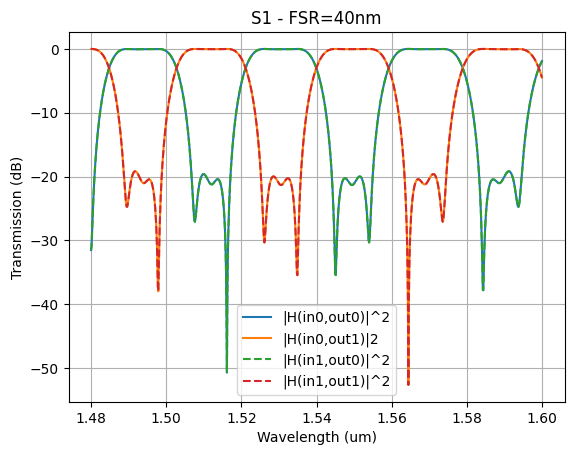

In [ ]:
# Simulación del circuito S1 con los parámetros obtenidos

L1 = 24.4674054040168
L2 = 10.0
Lpi =  0.3251102337981303
wvl= wvl_1000

alphau = 0
alphad = 0
alphau_np = (np.log(10.0)/20.0) * alphau   # neper/um
alphad_np = (np.log(10.0)/20.0) * alphad   # neper/um


# Coupling constant
k_a = np.full(wvl.shape, 0.5)
k_b = np.full(wvl.shape, 0.17)
k_c= np.full(wvl.shape, 0.23)
k_d= np.full(wvl.shape, 0.05)

neff= n_eff_base


s1 = s1_def(wl=wvl,
            coup_a={"coupling": k_a},
            wvg_u1={"wl":wvl, "neff": neff, "length": L1, "loss":alphau},
            wvg_d1={"wl":wvl, "neff": neff, "length": L2, "loss":alphad},
            coup_b={"coupling": k_b},

            wvg_u2={"wl":wvl, "neff": neff, "length": 2* L2, "loss": alphau},
            wvg_d2={"wl":wvl, "neff": neff, "length": 2* L1, "loss": alphad},
            coup_c={"coupling": k_c},

            wvg_u3={"wl":wvl, "neff": neff, "length": 2*L2, "loss": alphau},
            wvg_d3={"wl":wvl, "neff": neff, "length": 2*L1 + Lpi, "loss": alphad},
            coup_d={"coupling": k_d},   
            )

h00 = s1["in0", "out0"]
h01 = s1["in0", "out1"]
h11 = s1["in1", "out0"]
h10 = s1["in1", "out1"]

t00_dB = 10*np.log10(np.abs(h00)**2)
t01_dB = 10*np.log10(np.abs(h01)**2)
t10_dB = 10*np.log10(np.abs(h10)**2)
t11_dB = 10*np.log10(np.abs(h11)**2)


plt.figure()
plt.plot(wvl, t00_dB, label="|H(in0,out0)|^2")
plt.plot(wvl, t01_dB, label="|H(in0,out1)|2")
plt.plot(wvl, t10_dB, "--", label="|H(in1,out0)|^2")
plt.plot(wvl, t11_dB, "--", label="|H(in1,out1)|^2")
plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (dB)")
plt.title("S1 - FSR=40nm")
plt.legend()
plt.grid(True)
plt.show()

### 3.4. Diseño de S2

Ahora vamos a definir el *netlist* para la segunda etapa del (de)multiplexor, el circuito S2. 

Esta estructura es más corta: consta de 2 etapas en lugar de 3. Esto se debe a que las etapas subsiguientes del demultiplexor están diseñadas para separar diferentes espaciados de canales y requieren un diseño de interferencia distinto. Vamos a definirla de manera análoga al circuito S1 ajustándolo a estas 2 etapas.


In [146]:
#Definición del circuito S2
s2_def, info = sax.circuit(
    netlist={
        "instances": {
            "coup_a": "coupler",
            "wvg_u1": "waveguide",
            "wvg_d1": "waveguide",
            "coup_b": "coupler",

            "wvg_u2": "waveguide",
            "wvg_d2": "waveguide",

            "coup_c": "coupler",
        },
        "connections": {
            # Coupler a, b
            "coup_a,out0": "wvg_u1,in0",
            "wvg_u1,out0": "coup_b,in0",
            "coup_a,out1": "wvg_d1,in0",
            "wvg_d1,out0": "coup_b,in1",

            # Coupler b, c
            "coup_b,out0": "wvg_u2,in0",
            "wvg_u2,out0": "coup_c,in0",
            "coup_b,out1": "wvg_d2,in0",
            "wvg_d2,out0": "coup_c,in1",

        },
        "ports": {
            "in0": "coup_a,in0",
            "in1": "coup_a,in1",
            "out0": "coup_c,out0",
            "out1": "coup_c,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

**Asignación de los  parámetros:**
* **Longitudes de los brazos:** Se definen los valores base $L_1$ y $L_2$. 
* **Coeficientes de acoplo ($K$):** Se ajustan los valores de acoplo para los tres acopladores direccionales de esta etapa ($K_a = 0.5$, $K_b = 0.3$, $K_c = 0.05$). 

**Evaluación del modelo S2:**
Se introducen los parámetros en el netlist `s2_def`. La primera etapa del MZI utiliza las longitudes $L_1$ y $L_2$, mientras que la segunda etapa cruza y duplica estas longitudes ($2L_2$ y $2L_1$). Siguiendo este diseño: 

![My Image](Etapa_s2.PNG)


**Análisis de la Gráfica (Transmisión vs. Longitud de Onda):**
* **Rango Espectral Libre (FSR):** La característica más importante de esta gráfica es que el FSR se ha duplicado, alcanzando los **80 nm** (en comparación con los **40 nm** de la etapa S1). 
* **Perfil del Filtro:** Apreciamos la respuesta *flat-top* (banda de paso aplanada) en los máximos de transmisión, así como transiciones muy abruptas (*steep roll-off*) hacia los valles.

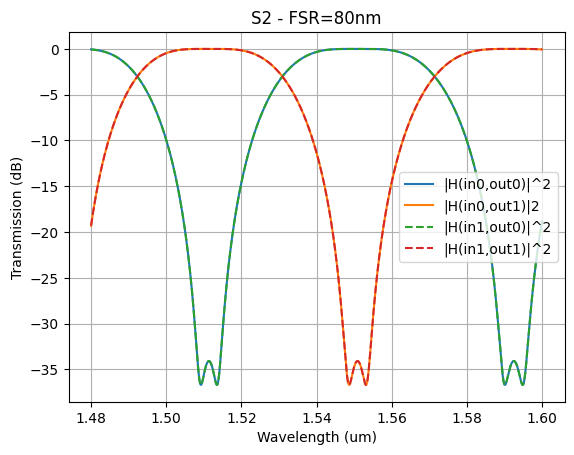

In [ ]:
# Simulación del circuito S2 con los parámetros obtenidos
L1 = 5
L2 = 11.9160
wvl= wvl_1000

K_a = np.full(wvl.shape, 0.5)
K_b = np.full(wvl.shape, 0.3)
K_c = np.full(wvl.shape, 0.05)

s2= s2_def(wl=wvl,
            coup_a={"coupling": K_a},
            wvg_u1={"wl":wvl, "neff": neff, "length": L1, "loss":alphau},
            wvg_d1={"wl":wvl, "neff": neff, "length": L2, "loss":alphad},
            coup_b={"coupling": K_b},

            wvg_u2={"wl":wvl, "neff": neff, "length": 2* L2, "loss": alphau},
            wvg_d2={"wl":wvl, "neff": neff, "length": 2* L1, "loss": alphad},
            coup_c={"coupling": K_c},   
            )

h00 = s2["in0", "out0"]
h01 = s2["in0", "out1"]
h11 = s2["in1", "out0"]
h10 = s2["in1", "out1"]

t00_dB = 10*np.log10(np.abs(h00)**2)
t01_dB = 10*np.log10(np.abs(h01)**2)
t10_dB = 10*np.log10(np.abs(h10)**2)
t11_dB = 10*np.log10(np.abs(h11)**2)


plt.figure()
plt.plot(wvl, t00_dB, label="|H(in0,out0)|^2")
plt.plot(wvl, t01_dB, label="|H(in0,out1)|2")
plt.plot(wvl, t10_dB, "--", label="|H(in1,out0)|^2")
plt.plot(wvl, t11_dB, "--", label="|H(in1,out1)|^2")
plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (dB)")
plt.title("S2 - FSR=80nm")
plt.legend()
plt.grid(True)
plt.show()

### 3.5. Diseño FINAL

En este apartado vamos a integrar S1 y S2 para construir el diseño completo del **(de)multiplexor CWDM de 4 canales**.

**3.5.1. Definición de las funciones (`funcion_s1` y `funcion_s2`)**
Para simplificar el circuito final.
* Se utiliza `sax.reciprocal(...)` para devolver un diccionario con los parámetros de dispersión (S-parameters), asumiendo que los componentes son ópticamente recíprocos. 

**3.5.2. Definición del Circuito Principal (`final_def`)**
Aquí es donde se define la arquitectura del dispositivo:
* **`instances`**: Definimos bloques `S1` para la primera etapa de división "gruesa" del espectro y bloques `S2` para las etapas de filtrado fino y separación de canales.
* **`connections`**: Se implementa el enrutamiento en cascada. La señal entra por `S1_entry` y se divide en dos ramas (`upper` y `lower`). Cada una de estas ramas pasa por etapas sucesivas (`S2_upper/lower` y `S2_port1-4`) que van filtrando progresivamente el espectro hasta aislar las bandas de paso deseadas. Esta configuración asegura el aplanamiento de la banda (flat-top) y minimiza la diafonía (crosstalk).
* **`ports`**: Se definen los puertos globales. Tenemos la entrada principal (`in_main`) donde se inyectaría la luz con todas las longitudes de onda, y cuatro puertos de salida distintos (`ch1`, `ch2`, `ch3`, `ch4`), cada uno destinado a recoger uno de los canales CWDM separados (1510 nm, 1530 nm, 1550 nm y 1570 nm).
* **`models`**: Se indica al simulador que cuando vea "S1" o "S2" en las instancias, debe ejecutar las funciones hemos definido.

In [ ]:
def funcion_s1(wvl=1.55, neff=1.6072, loss=0, L1=10.0, L2=10.0,
               k_a=0.5, k_b=0.17, k_c=0.23, k_d=0.05, Lpi=0.0) -> sax.SDict:
    s1 = s1_def(
        wl=wvl,
        coup_a={"coupling": k_a},
        wvg_u1={"wl": wvl, "neff": neff, "length": L1,       "loss": loss},
        wvg_d1={"wl": wvl, "neff": neff, "length": L2,       "loss": loss},
        coup_b={"coupling": k_b},
        wvg_u2={"wl": wvl, "neff": neff, "length": 2*L2,     "loss": loss},
        wvg_d2={"wl": wvl, "neff": neff, "length": 2*L1,     "loss": loss},
        coup_c={"coupling": k_c},
        wvg_u3={"wl": wvl, "neff": neff, "length": 2*L2,     "loss": loss},
        wvg_d3={"wl": wvl, "neff": neff, "length": 2*L1+Lpi, "loss": loss},
        coup_d={"coupling": k_d},
    )
    return sax.reciprocal({           # ← return DENTRO de la función
        ("in0", "out0"): s1["in0", "out0"],
        ("in0", "out1"): s1["in0", "out1"],
        ("in1", "out0"): s1["in1", "out0"],
        ("in1", "out1"): s1["in1", "out1"],
    })


def funcion_s2(wvl=1.55, neff=1.6072, loss=0.0, L1=10.0, L2=10.0,
               k_a=0.5, k_b=0.3, k_c=0.05) -> sax.SDict:
    s2 = s2_def(
        wl=wvl,
        coup_a={"coupling": k_a},
        wvg_u1={"wl": wvl, "neff": neff, "length": L1,   "loss": loss},
        wvg_d1={"wl": wvl, "neff": neff, "length": L2,   "loss": loss},
        coup_b={"coupling": k_b},
        wvg_u2={"wl": wvl, "neff": neff, "length": 2*L2, "loss": loss},
        wvg_d2={"wl": wvl, "neff": neff, "length": 2*L1, "loss": loss},
        coup_c={"coupling": k_c},
    )
    return sax.reciprocal({           
        ("in0", "out0"): s2["in0", "out0"],
        ("in0", "out1"): s2["in0", "out1"],
        ("in1", "out0"): s2["in1", "out0"],
        ("in1", "out1"): s2["in1", "out1"],
    })


# El ciruito final con S1 y S2 como subcircuitos
final_def, info = sax.circuit(
    netlist={
        "instances": {
            "S1_entry": "S1", "S1_upper": "S1", "S1_lower": "S1",
            "S2_upper": "S2", "S2_lower": "S2",
            "S2_port1": "S2", "S2_port2": "S2",
            "S2_port3": "S2", "S2_port4": "S2",
        },
        "connections": {
            "S1_entry,out0": "S1_upper,in1",
            "S1_entry,out1": "S1_lower,in1",
            "S1_upper,out0": "S2_upper,in1",
            "S1_lower,out1": "S2_lower,in0",
            "S2_upper,out0": "S2_port1,in1",
            "S2_upper,out1": "S2_port2,in0",
            "S2_lower,out0": "S2_port3,in1",
            "S2_lower,out1": "S2_port4,in0",
        },
        "ports": {
            "in_main": "S1_entry,in0",
            "in_aux":  "S1_entry,in1",
            "ch1": "S2_port1,out0",
            "ch2": "S2_port2,out0",
            "ch3": "S2_port3,out1",  # ← out1
            "ch4": "S2_port4,out1",  # ← out1
        },
    },
    models={"S1": funcion_s1, "S2": funcion_s2},
)

**3.5.3. Evaluacion del modelo final**

El modelo final a simualar es el siguiente:

![My Image](Global.PNG)

* Definimos el rango de longitudes de onda (`wvl`) barriendo desde 1.48 hasta 1.60 μm.
* Llamamos a nuestro circuito `final_def` y le pasamos a cada instancia (Stage 1, Stage 2...) sus coeficientes de acoplo ($k$) y longitudes correspondientes.
* A las instancias de las ramas inferiores (`S2_lower`, `S2_port3`, `S2_port4`) se les suma una pequeña longitud `despl_s2_b` a su longitud de brazo `L2`. Esto sirve para meter un desfase adicional y "desplazar" el espectro de esas ramas en el eje horizontal. Si no hiciéramos esto, la interferencia constructiva caería siempre en la misma longitud de onda y no podríamos separar los canales.

In [ ]:
# --- Evaluación del circuito SAX global
wvl = wvl_1000

# Desfase pi evaluado a 1540 nm
idx_1540 = np.argmin(np.abs(wvl - 1.540))
Lpi_s1 =  0.3251102337981303

# Coeficientes de acoplo
k_s1 = [0.5, 0.17, 0.23, 0.05]
k_s2 = [0.5, 0.3, 0.05]

# Simulamos el circuito completo llamando a 'final_def'
S_tree = final_def(
    
    # --- STAGE 1 
    S1_entry={
        "wvl": wvl, "neff": n_eff_base, "loss": 0, 
        "L1": l1_s1, "L2": l2_s1,
        "k_a": k_s1[0], "k_b": k_s1[1], "k_c": k_s1[2], "k_d": k_s1[3],
        "Lpi": Lpi_s1,
    },

    # --- STAGE 2 
    S1_upper={
        "wvl": wvl, "neff": n_eff_base, "loss": 0, 
        "L1": l1_s1, "L2": l2_s1,
        "k_a": k_s1[0], "k_b": k_s1[1], "k_c": k_s1[2], "k_d": k_s1[3],
        "Lpi": Lpi_s1,
    },
    S1_lower={
        "wvl": wvl, "neff": n_eff_base, "loss": 0, 
        "L1": l1_s1, "L2": l2_s1,
        "k_a": k_s1[0], "k_b": k_s1[1], "k_c": k_s1[2], "k_d": k_s1[3],
        "Lpi": Lpi_s1,
    },

    # --- STAGE 3 
    S2_upper={
        "wvl": wvl, "neff": n_eff_base, "loss": 0, 
        "L1": l1_s2, "L2": l2_s2,
        "k_a": k_s2[0], "k_b": k_s2[1], "k_c": k_s2[2],
    },
    S2_lower={
        "wvl": wvl, "neff": n_eff_base, "loss": 0, 
        "L1": l1_s2, "L2": l2_s2 + despl_s2_b,
        "k_a": k_s2[0], "k_b": k_s2[1], "k_c": k_s2[2],
    },

    # --- STAGE 4 (Output ports) 
    S2_port1={
        "wvl": wvl, "neff": n_eff_base, "loss": 0, 
        "L1": l1_s2, "L2": l2_s2,
        "k_a": k_s2[0], "k_b": k_s2[1], "k_c": k_s2[2],
    },
    S2_port2={
        "wvl": wvl, "neff": n_eff_base, "loss": 0, 
        "L1": l1_s2, "L2": l2_s2,
        "k_a": k_s2[0], "k_b": k_s2[1], "k_c": k_s2[2],
    },
    S2_port3={
        "wvl": wvl, "neff": n_eff_base, "loss": 0, 
        "L1": l1_s2, "L2": l2_s2 + despl_s2_b,
        "k_a": k_s2[0], "k_b": k_s2[1], "k_c": k_s2[2],
    },
    S2_port4={
        "wvl": wvl, "neff": n_eff_base, "loss": 0, 
        "L1": l1_s2, "L2": l2_s2 + despl_s2_b,
        "k_a": k_s2[0], "k_b": k_s2[1], "k_c": k_s2[2],
    },
)

**3.5.4. Análisis de la Gráfica Final:**

* **Separación de los 4 Canales:** Se diferencian cuatro picos distintos centrados a las longitudes de onda deseadas (con una separación de 20 nm): **1510 nm (Azul)**, **1530 nm (Naranja)**, **1550 nm (Rojo)** y **1570 nm (Verde)**. 
* **Perfil Flat-Top:** Los picos de transmisión están achatados por arriba. Esto es importante en la vida real porque hace que el dispositivo sea tolerante a errores de fabricación, así si hay una pequeña desviación, la señal se va a seguir transmitiendo casi al 100% de potencia.
* **Crosstalk (Diafonía) excelente:** En la gráfica se puede apreciar cómo el *roll-off* (la caída a los lados del pico) es muy vertical. Cuando un canal está en su máximo de transmisión (cerca de 0 dB), la potencia del resto de canales en esa misma longitud de onda se siyuan hasta los -40 dB o -50 dB. Esto asegura que la señal de un canal no se cruce por el puerto equivocado y genere ruido en la señal de los demás.

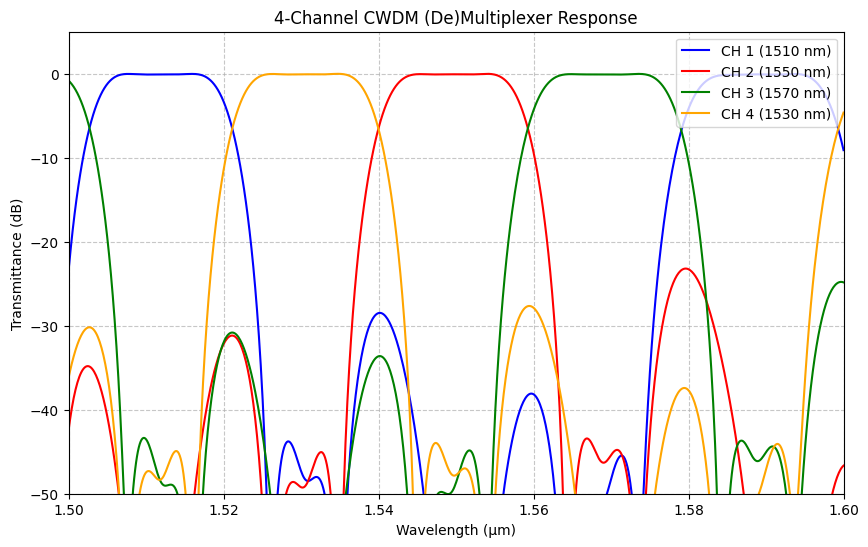

In [162]:
# Extraemos la respuesta desde la entrada principal a cada canal de salida.
# Utilizamos los nombres de los puertos globales definidos en el 'sax.circuit'
H1 = S_tree["in_aux", "ch1"]
H2 = S_tree["in_aux", "ch2"]
H3 = S_tree["in_aux", "ch3"]
H4 = S_tree["in_aux", "ch4"]

# Conversión a escala logarítmica (dB)
# Se añade un pequeño epsilon (1e-12) para evitar un posible error de log10(0)
T1 = 10 * np.log10(np.abs(H1)**2 + 1e-12)
T2 = 10 * np.log10(np.abs(H2)**2 + 1e-12)
T3 = 10 * np.log10(np.abs(H3)**2 + 1e-12)
T4 = 10 * np.log10(np.abs(H4)**2 + 1e-12)

plt.figure(figsize=(10, 6))

plt.plot(wvl, T1, label="CH 1 (1510 nm)", color="blue")
plt.plot(wvl, T2, label="CH 2 (1550 nm)", color="red")
plt.plot(wvl, T3, label="CH 3 (1570 nm)", color="green")
plt.plot(wvl, T4, label="CH 4 (1530 nm)", color="orange")

plt.xlim(1.50, 1.60)
plt.ylim(-50, 5)

plt.xlabel("Wavelength (μm)")
plt.ylabel("Transmittance (dB)")
plt.title("4-Channel CWDM (De)Multiplexer Response")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()

## **Part 2: Filter and die layout** 
---

#### **4. Layout of the CWDM (de)multiplexer filter employing GDSFactory+** 

### 4.1. Cálculo de las longitudes de acoplo

El primer paso antes de definir el layout del circuito en `gdsfactory` es determinar las longitudes físicas de los tramos rectos para los acopladores direccionales. Para ello, utilizamos la longitud de batido ($L_\pi$) que hemos extraído previamente..

La fracción de potencia que se transfiere al puerto cruzado ($K$) sigue la siguiente relación: 

$$L = \frac{2 L_\pi}{\pi} \left( \arcsin(\sqrt{K}) \right)$$

La longitud recta necesaria ($L$) se obtiene despejando de la misma.

Donde:
* **$L$**: Longitud del tramo recto del acoplador que introduciremos en el layout.
* **$L_\pi$**: Longitud necesaria para un acoplo del 100%.
* **$K$**: Ratio de acoplo objetivo para cada etapa del filtro (0.50, 0.17, etc.).


In [120]:
def calcular_longitud_acoplador(K_objetivo, Lc= 0.33):
   
    # Calculamos el coeficiente kappa
    kappa = np.pi / (2 * Lc)
    
    # Calculamos la longitud L
    L = (np.arcsin(np.sqrt(K_objetivo))) / kappa
    
    # Si las curvas ya acoplan más de lo que pedimos, L sería negativo
    return max(0.0, L)

L_050 = calcular_longitud_acoplador(0.50, Lpi_s1)
L_030 = calcular_longitud_acoplador(0.30, Lpi_s1)
L_023 = calcular_longitud_acoplador(0.23, Lpi_s1)
L_017 = calcular_longitud_acoplador(0.17, Lpi_s1)
L_005 = calcular_longitud_acoplador(0.05, Lpi_s1)


print(f"Longitud para K=0.50: {L_050*10**2:.5f} um")
print(f"Longitud para K=0.30: {L_030*10**2:.5f} um")
print(f"Longitud para K=0.23: {L_023*10**2:.5f} um")
print(f"Longitud para K=0.17: {L_017*10**2:.5f} um")
print(f"Longitud para K=0.05: {L_005*10**2:.5f} um")

Longitud para K=0.50: 16.25551 um
Longitud para K=0.30: 11.99690 um
Longitud para K=0.23: 10.35230 um
Longitud para K=0.17: 8.79606 um
Longitud para K=0.05: 4.66749 um


In [121]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells

### 4.2. Definición de Parámetros 

* **Geometría de la Guía (`WG_WIDTH`, `R_SMALL`, `R_LARGE`):** Fijamos el ancho de nuestras guías a 450 nm. Definimos dos radios de curvatura: 50 µm para las conexiones largas entre etapas y 35 µm para los brazos dentro de los MZI.
* **Longitudes ($L_1$, $L_2$, $L_\pi$):** Trasladamos las longitudes calculadas previamente a variables para el layout. 
* **Longitudes de acoplo (`DC_LENGTHS`):** Donde recogemos las longitudes calculadas en el apartado 3.1

In [163]:
# Radio de curvatura de los bends y anchura de guía de onda estándar
WG_WIDTH  = 0.45   
R_SMALL   = 35.0   
R_LARGE   = 50.0   

# Longitudes de los brazos
L1_S1     = 24.4674054040168   
L2_S1     = 10.0               
LPI_S1    = 0.32511           

L1_S2     = 5.0              
L2_S2_UP  = 11.9160           
L2_S2_BOT = 12.0767         

# Longitudes de acoplo para cada coeficiente (gap fijo = 0.4 um)
DC_LENGTHS = {
    0.50: 16.25551,
    0.30: 11.99690,
    0.23: 10.35230,
    0.17:  8.79606,
    0.05: 4.66749,
}
GAP = 0.4  

### 4.3. Diseño del Brazo de Retardo (Delay Arm)

In [164]:
@gf.cell
def delay_arm(arm_length: float) -> gf.Component:
    
    c = gf.Component()

    half = arm_length / 2.0

    #Componentes
    arc_a = c << gf.components.bend_circular(width=WG_WIDTH, radius=R_SMALL, angle=90)
    seg_a = c << cells.straight(width=WG_WIDTH, length=half)
    arc_b = c << gf.components.bend_circular(width=WG_WIDTH, radius=R_SMALL, angle=90)
    arc_c = c << gf.components.bend_circular(width=WG_WIDTH, radius=R_SMALL, angle=90)
    seg_b = c << cells.straight(width=WG_WIDTH, length=half)
    arc_d = c << gf.components.bend_circular(width=WG_WIDTH, radius=R_SMALL, angle=90)

    #Orientaciones
    arc_a.mirror_x()
    arc_d.mirror_x()

    kw = dict(allow_width_mismatch=True, allow_layer_mismatch=True,
              allow_type_mismatch=True, mirror=False)

    #Conexiones
    seg_a.connect("o1", arc_a.ports["o2"], **kw)
    arc_b.connect("o1", seg_a.ports["o2"], **kw)
    arc_c.connect("o1", arc_b.ports["o2"], **kw)
    seg_b.connect("o1", arc_c.ports["o2"], **kw)
    arc_d.connect("o1", seg_b.ports["o2"], **kw)

    #Puertos
    c.add_port("o1", center=arc_d.ports["o2"].center,
               width=WG_WIDTH, orientation=180, layer=(1, 0), port_type="optical")
    c.add_port("o2", center=arc_a.ports["o1"].center,
               width=WG_WIDTH, orientation=0,   layer=(1, 0), port_type="optical")
    return c

### 4.4. Diseño etapa S1

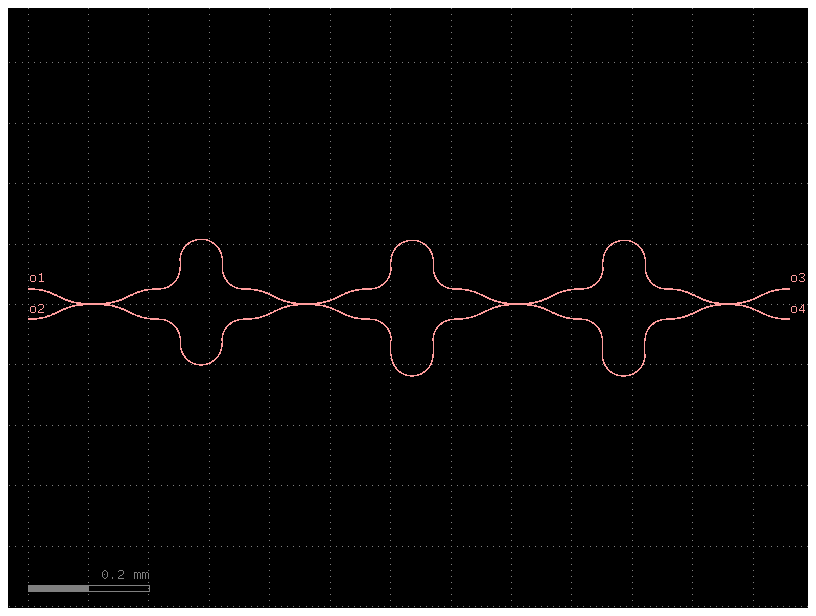

In [165]:
@gf.cell
def stage_S1() -> gf.Component:
    
    c = gf.Component()
    kw = dict(allow_width_mismatch=True, allow_layer_mismatch=True,
              allow_type_mismatch=True)

    #Acopladores
    cp_50 = c << cells.coupler(length=DC_LENGTHS[0.50], gap=GAP)
    cp_17 = c << cells.coupler(length=DC_LENGTHS[0.17], gap=GAP)
    cp_23 = c << cells.coupler(length=DC_LENGTHS[0.23], gap=GAP)
    cp_05 = c << cells.coupler(length=DC_LENGTHS[0.05], gap=GAP)

    #MZI 1: L1 / L2
    arm1_long  = c << delay_arm(L1_S1)
    arm1_short = c << delay_arm(L2_S1)

    #MZI 2: 2·L1 / 2·L2
    arm2_long  = c << delay_arm(2 * L1_S1)
    arm2_short = c << delay_arm(2 * L2_S1)

    #MZI 3: 2·L1 + L_pi / 2·L2
    arm3_long  = c << delay_arm(2 * L1_S1 + LPI_S1)
    arm3_short = c << delay_arm(2 * L2_S1)

    #Conexiones
    arm1_long.connect( "o1", cp_50.ports["o3"], **kw, mirror=False)
    arm1_short.connect("o1", cp_50.ports["o4"], **kw, mirror=True)
    cp_17.connect("o2", arm1_long.ports["o2"],  **kw, mirror=False)

    arm2_short.connect("o1", cp_17.ports["o3"], **kw, mirror=False)
    arm2_long.connect( "o1", cp_17.ports["o4"], **kw, mirror=True)
    cp_23.connect("o2", arm2_short.ports["o2"], **kw, mirror=False)

    arm3_short.connect("o1", cp_23.ports["o3"], **kw, mirror=False)
    arm3_long.connect( "o1", cp_23.ports["o4"], **kw, mirror=True)
    cp_05.connect("o2", arm3_short.ports["o2"], **kw, mirror=False)

    #Puertos 
    c.add_port("o1", center=cp_50.ports["o2"].center,
               width=WG_WIDTH, orientation=180, layer=(1,0), port_type="optical")
    c.add_port("o2", center=cp_50.ports["o1"].center,
               width=WG_WIDTH, orientation=180, layer=(1,0), port_type="optical")
    c.add_port("o3", center=cp_05.ports["o3"].center,
               width=WG_WIDTH, orientation=0,   layer=(1,0), port_type="optical")
    c.add_port("o4", center=cp_05.ports["o4"].center,
               width=WG_WIDTH, orientation=0,   layer=(1,0), port_type="optical")
    return c

c = gf.Component()
ref = c << stage_S1()
c.add_ports(ref.ports)
c.draw_ports()
c.plot()

### 4.5. Diseño etapa S2

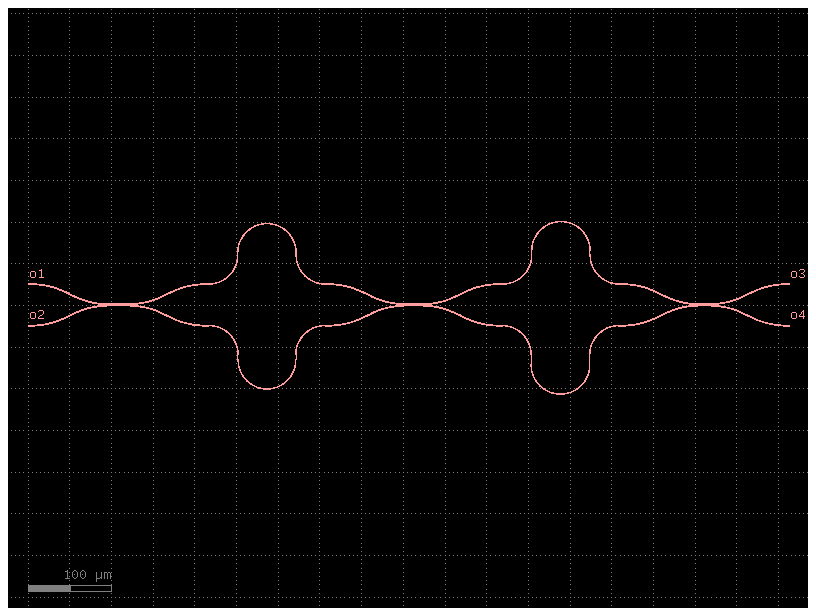

In [ ]:
@gf.cell
def stage_S2(long_arm: float = L2_S2_UP) -> gf.Component:

    c = gf.Component()
    kw = dict(allow_width_mismatch=True, allow_layer_mismatch=True,
              allow_type_mismatch=True)

    #Acopladores
    cp_50 = c << cells.coupler(length=DC_LENGTHS[0.50], gap=GAP)
    cp_30 = c << cells.coupler(length=DC_LENGTHS[0.30], gap=GAP)
    cp_05 = c << cells.coupler(length=DC_LENGTHS[0.05], gap=GAP)

    # MZI 1
    arm1_short = c << delay_arm(L1_S2)
    arm1_long  = c << delay_arm(long_arm)

    # MZI 2
    arm2_short = c << delay_arm(2 * L1_S2)
    arm2_long  = c << delay_arm(2 * long_arm)

    #Conexiones
    arm1_short.connect("o1", cp_50.ports["o3"], **kw, mirror=False)
    arm1_long.connect( "o1", cp_50.ports["o4"], **kw, mirror=True)
    cp_30.connect("o2", arm1_short.ports["o2"], **kw, mirror=False)

    arm2_short.connect("o1", cp_30.ports["o3"], **kw, mirror=False)
    arm2_long.connect( "o1", cp_30.ports["o4"], **kw, mirror=True)
    cp_05.connect("o2", arm2_short.ports["o2"], **kw, mirror=False)

    c.add_port("o1", center=cp_50.ports["o2"].center,
               width=WG_WIDTH, orientation=180, layer=(1,0), port_type="optical")
    c.add_port("o2", center=cp_50.ports["o1"].center,
               width=WG_WIDTH, orientation=180, layer=(1,0), port_type="optical")
    c.add_port("o3", center=cp_05.ports["o3"].center,
               width=WG_WIDTH, orientation=0,   layer=(1,0), port_type="optical")
    c.add_port("o4", center=cp_05.ports["o4"].center,
               width=WG_WIDTH, orientation=0,   layer=(1,0), port_type="optical")
    return c

c = gf.Component()
ref = c << stage_S2()
c.add_ports(ref.ports)
c.draw_ports()
c.plot()

### 4.5. Diseño final

* **Estructura en cascada (Etapas 1 a 4):** Se conectan los bloques siguiendo la topología de árbol (1×S1 → 2×S1 → 2×S2 → 4×S2). A las ramas inferiores se les asigna la longitud `L2_S2_BOT` para introducir el desfase físico necesario que separa los canales.
* **Conexiones y Puertos I/O:** Se usan curvas en U (`_u_bend`) para unir las etapas.

In [168]:
def _u_bend(parent: gf.Component, port_start, mirror_first: bool = False):
    kw = dict(allow_width_mismatch=True, allow_layer_mismatch=True,
              allow_type_mismatch=True)

    #Componentes
    b1 = parent << gf.components.bend_circular(width=WG_WIDTH, radius=R_LARGE, angle=90)
    b2 = parent << gf.components.bend_circular(width=WG_WIDTH, radius=R_LARGE, angle=90)
    seg = parent << cells.straight(width=WG_WIDTH, length=50)

    #Conexiones
    b1.connect("o1", port_start, **kw, mirror=mirror_first)
    seg.connect("o1", b1.ports["o2"], **kw, mirror=False)
    b2.connect("o1", seg.ports["o2"], **kw, mirror=(not mirror_first))

    return b2.ports["o2"]

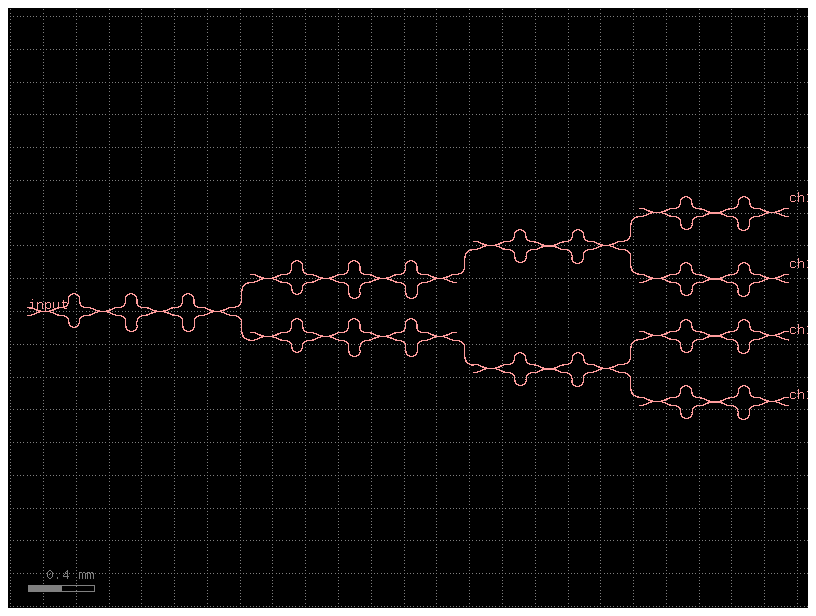

In [169]:
@gf.cell
def layout_final() -> gf.Component:
    """
    Demultiplexor CWDM de 4 canales (1510/1530/1550/1570 nm) basado en
    MZIs en cascada de 4 etapas: 1×S1 → 2×S1 → 2×S2 → 4×S2.
    Topología según Fig. 5(a) de Yen & Hung, JLT 2021.
    """
    c = gf.Component()
    kw = dict(allow_width_mismatch=True, allow_layer_mismatch=True,
              allow_type_mismatch=True)

    # -- Etapa 1 ---------------------------------------------------
    e1 = c << stage_S1()

    # -- Etapa 2 ---------------------------------------------------
    e2_top = c << stage_S1()
    e2_bot = c << stage_S1()

    p_top = _u_bend(c, e1.ports["o3"], mirror_first=False)
    p_bot = _u_bend(c, e1.ports["o4"], mirror_first=True)

    e2_top.connect("o2", p_top, **kw, mirror=False)
    e2_bot.connect("o2", p_bot, **kw, mirror=False)

    # -- Etapa 3 ---------------------------------------------------
    e3_top = c << stage_S2(long_arm=L2_S2_UP)
    e3_bot = c << stage_S2(long_arm=L2_S2_BOT)

    p_3t = _u_bend(c, e2_top.ports["o3"], mirror_first=False)
    p_3b = _u_bend(c, e2_bot.ports["o4"], mirror_first=True)

    e3_top.connect("o2", p_3t, **kw, mirror=False)
    e3_bot.connect("o1", p_3b, **kw, mirror=False)

    # -- Etapa 4 ---------------------------------------------------
    e4_ch1 = c << stage_S2(long_arm=L2_S2_UP)
    e4_ch2 = c << stage_S2(long_arm=L2_S2_UP)
    e4_ch3 = c << stage_S2(long_arm=L2_S2_BOT)
    e4_ch4 = c << stage_S2(long_arm=L2_S2_BOT)

    p_4a = _u_bend(c, e3_top.ports["o3"], mirror_first=False)
    p_4b = _u_bend(c, e3_top.ports["o4"], mirror_first=True)
    p_4c = _u_bend(c, e3_bot.ports["o3"], mirror_first=False)
    p_4d = _u_bend(c, e3_bot.ports["o4"], mirror_first=True)

    e4_ch1.connect("o2", p_4a, **kw, mirror=False)
    e4_ch2.connect("o1", p_4b, **kw, mirror=False)
    e4_ch3.connect("o2", p_4c, **kw, mirror=False)
    e4_ch4.connect("o1", p_4d, **kw, mirror=False)

    # -- Puertos globales ----------------------------------------------------
    c.add_port("input",  center=e1.ports["o2"].center,
               width=WG_WIDTH, orientation=180, layer=(1,0), port_type="optical")
    c.add_port("ch1510", center=e4_ch1.ports["o3"].center,
               width=WG_WIDTH, orientation=0,   layer=(1,0), port_type="optical")
    c.add_port("ch1550", center=e4_ch2.ports["o3"].center,
               width=WG_WIDTH, orientation=0,   layer=(1,0), port_type="optical")
    c.add_port("ch1570", center=e4_ch3.ports["o4"].center,
               width=WG_WIDTH, orientation=0,   layer=(1,0), port_type="optical")
    c.add_port("ch1530", center=e4_ch4.ports["o4"].center,
               width=WG_WIDTH, orientation=0,   layer=(1,0), port_type="optical")
    return c

c = gf.Component()
ref = c << layout_final()
c.add_ports(ref.ports)
c.draw_ports()
c.plot()

#### **5. Layout of the Whole Die and Test Structures** 

### 5.1. Diseño del *Die*

In [ ]:
@gf.cell
def die_with_trenches(size: tuple[float, float] = (12500, 3750),trench_width:float = 50, layer_deeptrench:str=(4, 0)) -> gf.Component:
    """This code generates a die 
    Args:
        size: the size of the die, in um.
        trench_width: width of the security trenches
        layer_deeptrench
    """
    c = gf.Component()
    fp = gf.c.rectangle(size=size, layer=layer_deeptrench, centered=True, port_type=None)
    fp2 = gf.c.rectangle(size=(size[0]-2*trench_width,size[1]-2*trench_width), layer=layer_deeptrench, centered=True, port_type=None)
    c << gf.boolean(fp, fp2, operation="not", layer=layer_deeptrench)
    c.add_port(name="o1", center=(0, 0), width=20, orientation=0, layer=layer_deeptrench)
    c.add_port(name="o2", center=(0, size[1]/2-trench_width), width=20, orientation=-90, layer=layer_deeptrench)
    c.add_port(name="o3", center=(size[0]/2-trench_width, 0), width=20, orientation=180, layer=layer_deeptrench)
    c.add_port(name="o4", center=(0, -size[1]/2+trench_width), width=20, orientation=90, layer=layer_deeptrench)
    c.add_port(name="o5", center=(-size[0]/2+trench_width, 0), width=20, orientation=0, layer=layer_deeptrench)

    return c

### 5.2. Diseño final incorporado en el *Die* + Exportación

* **Integración en el *Die*:** El circuito fotónico lo integramos y encuadramos dentro de la "plantilla"(`die_with_trenches`) usando la función `dmove`.
* **Puertos:** Se añaden guías rectas de 500 µm en los extremos de los puertos para permitir el acoplamiento de la fibra óptica en los límites del *die*
* **Exportación:** El diseño final lo guardamos en formato `.gds` en el archivo `test_gds`.

WindowsPath('C:/Users/cfp/DISEÑO/pic-upv-lab5-finalproject/test_gds.gds')

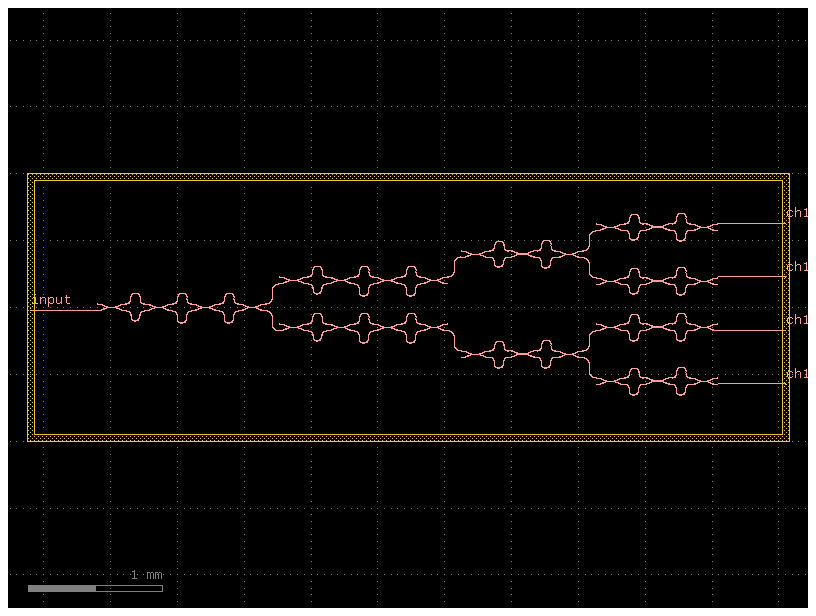

In [171]:
@gf.cell
def layout_final1() -> gf.Component:

    c = gf.Component()
    kw = dict(allow_width_mismatch=True, allow_layer_mismatch=True,
              allow_type_mismatch=True)

    # -- Etapa 1 ---------------------------------------------------
    e1 = c << stage_S1()

   # -- Etapa 2 ---------------------------------------------------
    e2_top = c << stage_S1()
    e2_bot = c << stage_S1()

    p_top = _u_bend(c, e1.ports["o3"], mirror_first=False)
    p_bot = _u_bend(c, e1.ports["o4"], mirror_first=True)

    e2_top.connect("o2", p_top, **kw, mirror=False)
    e2_bot.connect("o2", p_bot, **kw, mirror=False)

    # -- Etapa 3 ---------------------------------------------------
    e3_top = c << stage_S2(long_arm=L2_S2_UP)
    e3_bot = c << stage_S2(long_arm=L2_S2_BOT)

    p_3t = _u_bend(c, e2_top.ports["o3"], mirror_first=False)
    p_3b = _u_bend(c, e2_bot.ports["o4"], mirror_first=True)

    e3_top.connect("o2", p_3t, **kw, mirror=False)
    e3_bot.connect("o1", p_3b, **kw, mirror=False)

    # -- Etapa 4 ---------------------------------------------------
    e4_ch1 = c << stage_S2(long_arm=L2_S2_UP)
    e4_ch2 = c << stage_S2(long_arm=L2_S2_UP)
    e4_ch3 = c << stage_S2(long_arm=L2_S2_BOT)
    e4_ch4 = c << stage_S2(long_arm=L2_S2_BOT)

    p_4a = _u_bend(c, e3_top.ports["o3"], mirror_first=False)
    p_4b = _u_bend(c, e3_top.ports["o4"], mirror_first=True)
    p_4c = _u_bend(c, e3_bot.ports["o3"], mirror_first=False)
    p_4d = _u_bend(c, e3_bot.ports["o4"], mirror_first=True)

    e4_ch1.connect("o2", p_4a, **kw, mirror=False)
    e4_ch2.connect("o1", p_4b, **kw, mirror=False)
    e4_ch3.connect("o2", p_4c, **kw, mirror=False)
    e4_ch4.connect("o1", p_4d, **kw, mirror=False)

    # -- Guía de entrada ---------------------------------------------------
    wg_in = c << cells.straight(width=WG_WIDTH, length=500)
    wg_in.connect("o1", e1.ports["o2"], **kw, mirror=False)

    # -- Guías de salida por canal ----------------------------------------
    wg_ch1510 = c << cells.straight(width=WG_WIDTH, length=500)
    wg_ch1550 = c << cells.straight(width=WG_WIDTH, length=500)
    wg_ch1570 = c << cells.straight(width=WG_WIDTH, length=500)
    wg_ch1530 = c << cells.straight(width=WG_WIDTH, length=500)

    wg_ch1510.connect("o1", e4_ch1.ports["o3"], **kw, mirror=False)
    wg_ch1550.connect("o1", e4_ch2.ports["o3"], **kw, mirror=False)
    wg_ch1570.connect("o1", e4_ch3.ports["o4"], **kw, mirror=False)
    wg_ch1530.connect("o1", e4_ch4.ports["o4"], **kw, mirror=False)

    # -- Puertos globales ---------------------------------------------------
    c.add_port("input",  center=wg_in.ports["o2"].center,
               width=WG_WIDTH, orientation=180, layer=(1,0), port_type="optical")
    c.add_port("ch1510", center=wg_ch1510.ports["o2"].center,
               width=WG_WIDTH, orientation=0, layer=(1,0), port_type="optical")
    c.add_port("ch1550", center=wg_ch1550.ports["o2"].center,
               width=WG_WIDTH, orientation=0, layer=(1,0), port_type="optical")
    c.add_port("ch1570", center=wg_ch1570.ports["o2"].center,
               width=WG_WIDTH, orientation=0, layer=(1,0), port_type="optical")
    c.add_port("ch1530", center=wg_ch1530.ports["o2"].center,
               width=WG_WIDTH, orientation=0, layer=(1,0), port_type="optical")

    return c


c = gf.Component()
die = c << die_with_trenches(size=(5700, 2000))
die.dmove((2230, 0))
ref = c << layout_final1()
c.add_port("input",  port=ref.ports["input"])
c.add_port("ch1510", port=ref.ports["ch1510"])
c.add_port("ch1550", port=ref.ports["ch1550"])
c.add_port("ch1570", port=ref.ports["ch1570"])
c.add_port("ch1530", port=ref.ports["ch1530"])
c.draw_ports()
c.plot()

# Exportar GDS
output_path = r'C:\Users\cfp\DISEÑO\pic-upv-lab5-finalproject'
c.write_gds(output_path + "/test_gds.gds", with_metadata=False)